# Lab 05 — HOG-Based Industrial Defect Detection and Classification

**Pipeline:** Image → Preprocessing (resize + grayscale) → HOG feature extraction → ML classifier (SVM, Random Forest, …) → **Defective / Non-Defective** decision → **ACCEPT / REJECT**

**Dataset:** NEU Surface Defect Database (Kaggle `sovitrath/neu-steel-surface-defect-detecttrainvalid-split`) — 1,800 grayscale 200×200 hot-rolled steel images, 6 defect classes (crazing, inclusion, patches, pitted surface, rolled-in scale, scratches).

> **Important note on "Normal" images.** NEU-DET contains *only defective* surfaces — it has no defect-free class. To build the binary task (Class 0 = Non-defective, Class 1 = Defective) this notebook either
> 1. uses real defect-free images if you set `NORMAL_DIR` to a folder of them, or (default)
> 2. synthesises defect-free steel-like textures with the same size/intensity statistics.
>
> The 6-class task (the "advanced" version of the lab) uses **only real NEU-DET labels**, so it is unaffected by this issue.
>
> If the NEU dataset cannot be found (no Kaggle / no internet) the whole notebook falls back to a fully synthetic stand-in dataset so that every cell still runs end-to-end — exactly like the earlier labs. **Re-run on Kaggle with the dataset attached to get your real numbers; the report in the last cell is generated from whatever this run produced.**

In [1]:
import os, re, time, json, warnings
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt, seaborn as sns
from skimage.feature import hog
from skimage import exposure
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
import joblib
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
IMG_SIZE = 128
CLASSES = ["crazing", "inclusion", "patches", "pitted_surface", "rolled-in_scale", "scratches"]
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")


KAGGLE_NATIVE_PATH = "/kaggle/input/neu-steel-surface-defect-detecttrainvalid-split"
LOCAL_DATA_DIR = None
NORMAL_DIR = None
N_SYNTH_PER_CLASS = int(os.environ.get("LAB5_SYNTH_N", 300))
OUT_DIR = "lab5_outputs"
os.makedirs(OUT_DIR, exist_ok=True)
print("OpenCV", cv2.__version__)

OpenCV 5.0.0


## Task 1 — Load and inspect the industrial image dataset

In [2]:

def _norm(x):
    return (x - x.mean()) / (x.std() + 1e-6)

def steel_texture(rng, s=200):
    base = rng.uniform(100, 150)
    fine = _norm(cv2.GaussianBlur(rng.normal(0, 1, (s, s)).astype(np.float32), (0, 0), 1.2)) * 6
    mid = _norm(cv2.GaussianBlur(rng.normal(0, 1, (s, s)).astype(np.float32), (0, 0), 14)) * 9
    streak = _norm(cv2.GaussianBlur(rng.normal(0, 1, (s, s)).astype(np.float32), (0, 0), sigmaX=25, sigmaY=0.8)) * 6
    grad = np.linspace(-1, 1, s)[None, :] * rng.uniform(-12, 12)
    return base + fine + mid + streak + grad

def _paint(img, mask, amp):
    m = cv2.GaussianBlur(mask.astype(np.float32), (0, 0), 0.8) / 255.0
    return img - amp * m

def add_defect(img, cls, rng):
    s = img.shape[0]
    mask = np.zeros((s, s), np.uint8)
    if cls == 0:
        for _ in range(rng.integers(35, 70)):
            p = rng.integers(0, s, 2); pts = [p.copy()]
            for _ in range(rng.integers(3, 7)):
                p = np.clip(p + rng.integers(-18, 19, 2), 0, s - 1); pts.append(p.copy())
            cv2.polylines(mask, [np.array(pts, np.int32)], False, 255, 1)
        return _paint(img, mask, rng.uniform(22, 34))
    if cls == 1:
        for _ in range(rng.integers(3, 8)):
            c = tuple(int(v) for v in rng.integers(20, s - 20, 2))
            ax = (int(rng.integers(4, 12)), int(rng.integers(2, 5)))
            cv2.ellipse(mask, c, ax, float(rng.integers(0, 180)), 0, 360, 255, -1)
        return _paint(img, mask, rng.uniform(45, 70))
    if cls == 2:
        noise = cv2.GaussianBlur(rng.normal(0, 1, (s, s)).astype(np.float32), (0, 0), 14)
        mask = ((_norm(noise) > rng.uniform(0.6, 1.0)) * 255).astype(np.uint8)
        return _paint(img, mask, rng.uniform(30, 48)) + rng.normal(0, 4, (s, s))
    if cls == 3:
        for _ in range(rng.integers(2, 5)):
            c = rng.integers(25, s - 25, 2)
            for _ in range(rng.integers(40, 90)):
                q = np.clip(c + rng.normal(0, 18, 2), 0, s - 1).astype(int)
                cv2.circle(mask, (int(q[0]), int(q[1])), int(rng.integers(1, 4)), 255, -1)
        return _paint(img, mask, rng.uniform(40, 60))
    if cls == 4:
        for _ in range(rng.integers(300, 500)):
            p = rng.integers(0, s, 2); a = rng.uniform(0, np.pi); L = rng.integers(3, 9)
            q = (p + L * np.array([np.cos(a), np.sin(a)])).astype(int)
            cv2.line(mask, (int(p[0]), int(p[1])), (int(q[0]), int(q[1])), 255, 1)
        return _paint(img, mask, rng.uniform(18, 28))
    for _ in range(rng.integers(2, 6)):
        x0 = int(rng.integers(10, s - 10)); L = int(rng.integers(80, 190)); y0 = int(rng.integers(0, s - L // 2))
        a = np.deg2rad(rng.uniform(-15, 15))
        cv2.line(mask, (x0, y0), (int(x0 + L * np.sin(a)), int(y0 + L * np.cos(a))), 255, int(rng.integers(1, 3)))
    return _paint(img, mask, rng.uniform(30, 50))

def make_synthetic_sample(cls, seed):
    rng = np.random.default_rng(seed)
    img = steel_texture(rng)
    if cls is not None:
        img = add_defect(img, cls, rng)
    img = img + rng.normal(0, 2.0, img.shape)
    return np.clip(img, 0, 255).astype(np.uint8)

def preprocess(img):

    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

def find_real_dataset():
    roots = []
    if LOCAL_DATA_DIR and os.path.isdir(LOCAL_DATA_DIR): roots.append(LOCAL_DATA_DIR)
    if os.path.isdir(KAGGLE_NATIVE_PATH): roots.append(KAGGLE_NATIVE_PATH)
    if not roots:
        try:
            import kagglehub
            roots.append(kagglehub.dataset_download("sovitrath/neu-steel-surface-defect-detecttrainvalid-split"))
        except Exception as e:
            print(f"Could not obtain NEU-DET ({str(e)[:80]}). Using synthetic fallback.")
    pat = re.compile(r"^(" + "|".join(CLASSES) + r")")
    for root in roots:
        items = []
        for dp, _, files in os.walk(root):
            for f in sorted(files):
                m = pat.match(f.lower())
                if f.lower().endswith(IMG_EXT) and m:
                    items.append((os.path.join(dp, f), CLASSES.index(m.group(1))))
        if items:
            return items
    return None

real_items = find_real_dataset()
raw_imgs, y_multi = [], []
if real_items:
    USING_SYNTHETIC = False
    for p, c in real_items:
        raw_imgs.append(preprocess(cv2.imread(p)));  y_multi.append(c)
    print(f"REAL NEU-DET loaded: {len(raw_imgs)} defective images")
else:
    USING_SYNTHETIC = True
    for c in range(6):
        for i in range(N_SYNTH_PER_CLASS):
            raw_imgs.append(preprocess(make_synthetic_sample(c, 1000 * c + i)));  y_multi.append(c)
    print(f"!! SYNTHETIC stand-in dataset generated: {len(raw_imgs)} defective images")

n_def = len(raw_imgs)
n_norm = max(n_def // 3, 30)
normal_source = "synthetic defect-free textures"
if NORMAL_DIR and os.path.isdir(NORMAL_DIR):
    files = [os.path.join(NORMAL_DIR, f) for f in sorted(os.listdir(NORMAL_DIR)) if f.lower().endswith(IMG_EXT)][:n_norm]
    for f in files:
        raw_imgs.append(preprocess(cv2.imread(f)));  y_multi.append(-1)
    normal_source = f"real defect-free images from {NORMAL_DIR}"
else:
    for i in range(n_norm):
        raw_imgs.append(preprocess(make_synthetic_sample(None, 900000 + i)));  y_multi.append(-1)

X_imgs = np.array(raw_imgs, dtype=np.uint8)
y_multi = np.array(y_multi)
y_bin = (y_multi >= 0).astype(int)
print("Normal source:", normal_source)
print("Image tensor:", X_imgs.shape, "| binary counts [normal, defective]:", np.bincount(y_bin))
print("Per-class counts:", {("normal" if k < 0 else CLASSES[k]): int((y_multi == k).sum()) for k in np.unique(y_multi)})

Could not obtain NEU-DET (403 Client Error.

You don't have permission to access resource at URL: https://). Using synthetic fallback.
!! SYNTHETIC stand-in dataset generated: 1800 defective images
Normal source: synthetic defect-free textures
Image tensor: (2400, 128, 128) | binary counts [normal, defective]: [ 600 1800]
Per-class counts: {'normal': 600, 'crazing': 300, 'inclusion': 300, 'patches': 300, 'pitted_surface': 300, 'rolled-in_scale': 300, 'scratches': 300}


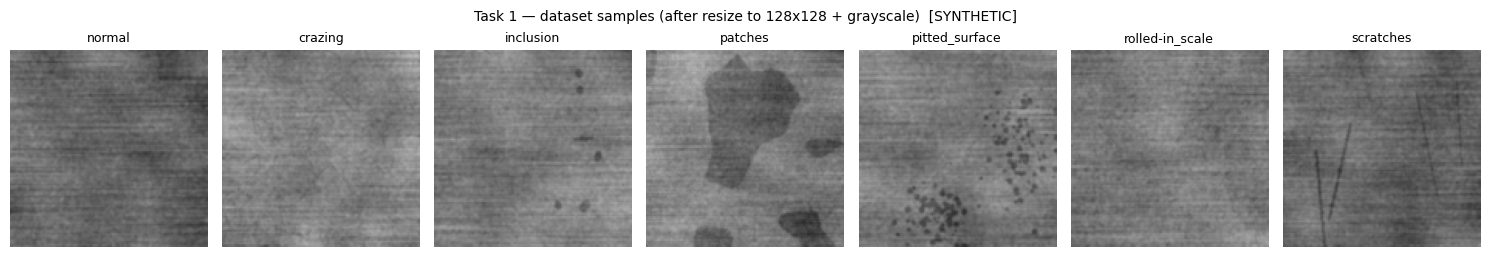

In [3]:

fig, axes = plt.subplots(1, 7, figsize=(15, 2.6))
names = ["normal"] + CLASSES
reps = [X_imgs[np.where(y_multi == k)[0][0]] for k in [-1] + list(range(6))]
for ax, im, n in zip(axes, reps, names):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255); ax.set_title(n, fontsize=9); ax.axis("off")
plt.suptitle("Task 1 — dataset samples (after resize to %dx%d + grayscale)%s" %
             (IMG_SIZE, IMG_SIZE, "  [SYNTHETIC]" if USING_SYNTHETIC else ""), fontsize=10)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_samples.png", dpi=150); plt.show()

## Tasks 2–3 — Common resolution, grayscale, and train / validation / test split

`preprocess()` above resizes every image to **128×128** (INTER_AREA) and converts to grayscale. A stratified **70 / 15 / 15** split is used; HOG settings are selected on the **validation** set and the **test** set is only used for the final reported numbers.

In [4]:
strat = np.where(y_multi < 0, 6, y_multi)
idx = np.arange(len(X_imgs))
tr_idx, tmp_idx = train_test_split(idx, test_size=0.30, stratify=strat, random_state=SEED)
va_idx, te_idx = train_test_split(tmp_idx, test_size=0.50, stratify=strat[tmp_idx], random_state=SEED)

Xtr_img, Xva_img, Xte_img = X_imgs[tr_idx], X_imgs[va_idx], X_imgs[te_idx]
ytr, yva, yte = y_bin[tr_idx], y_bin[va_idx], y_bin[te_idx]
mtr, mva, mte = y_multi[tr_idx], y_multi[va_idx], y_multi[te_idx]
split_info = pd.DataFrame({"Split": ["Train", "Validation", "Test"],
                           "Images": [len(tr_idx), len(va_idx), len(te_idx)],
                           "Non-defective": [(ytr == 0).sum(), (yva == 0).sum(), (yte == 0).sum()],
                           "Defective": [(ytr == 1).sum(), (yva == 1).sum(), (yte == 1).sum()]})
display(split_info)

,Split,Images,Non-defective,Defective
0,Train,1680,420,1260
1,Validation,360,90,270
2,Test,360,90,270


## Tasks 4–5 — HOG feature extraction and visualisation

HOG divides the image into small **cells**, builds a histogram of gradient orientations in each cell, and normalises over overlapping **blocks** (2×2 cells, L2-Hys). Baseline setting: **8×8 cells, 9 orientations**.

HOG vector length  cell 4/8/16, ori 9 -> [34596, 8100, 1764]


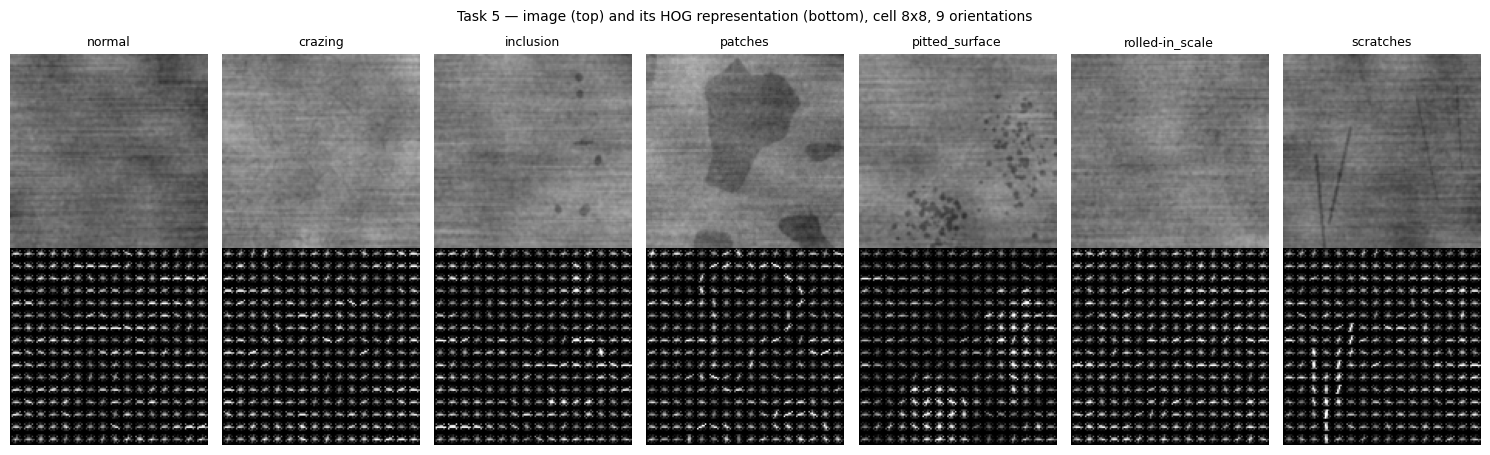

In [5]:
def hog_one(img, cell=8, ori=9, vis=False):
    return hog(img, orientations=ori, pixels_per_cell=(cell, cell), cells_per_block=(2, 2),
               block_norm="L2-Hys", feature_vector=True, visualize=vis)

def extract_hog(imgs, cell=8, ori=9):
    return np.array([hog_one(im, cell, ori) for im in imgs], dtype=np.float32)

print("HOG vector length  cell 4/8/16, ori 9 ->",
      [len(hog_one(Xtr_img[0], c, 9)) for c in (4, 8, 16)])

fig, axes = plt.subplots(2, 7, figsize=(15, 4.6))
for j, (im, n) in enumerate(zip(reps, names)):
    _, h = hog_one(im, 8, 9, vis=True)
    h = exposure.rescale_intensity(h, in_range=(0, np.percentile(h, 99.5) + 1e-9))
    axes[0, j].imshow(im, cmap="gray", vmin=0, vmax=255); axes[0, j].set_title(n, fontsize=9); axes[0, j].axis("off")
    axes[1, j].imshow(h, cmap="gray"); axes[1, j].axis("off")
axes[0, 0].set_ylabel("image");
plt.suptitle("Task 5 — image (top) and its HOG representation (bottom), cell 8x8, 9 orientations", fontsize=10)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_hog.png", dpi=150); plt.show()

## Tasks 6, 11 — HOG + SVM and the effect of HOG parameters (cell size × orientations)

Required grid: cell sizes **4×4, 8×8, 16×16** × orientations **6, 9, 12** (9 runs) with an RBF-SVM (`C=10`, balanced class weights). The best configuration is chosen by **validation F1 (defective class)**; test metrics are reported for every run for the report table.

In [6]:
def bin_metrics(y, p):
    return dict(Accuracy=accuracy_score(y, p), Precision=precision_score(y, p, zero_division=0),
                Recall=recall_score(y, p, zero_division=0), F1=f1_score(y, p, zero_division=0))

sweep_rows = []
for cell in (4, 8, 16):
    for ori in (6, 9, 12):
        t0 = time.time()
        Ftr, Fva, Fte = (extract_hog(a, cell, ori) for a in (Xtr_img, Xva_img, Xte_img))
        svm = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced").fit(Ftr, ytr)
        mv, mt = bin_metrics(yva, svm.predict(Fva)), bin_metrics(yte, svm.predict(Fte))
        sweep_rows.append(dict(Cell=f"{cell}x{cell}", cell=cell, Orient=ori, Dim=Ftr.shape[1],
                               Val_F1=mv["F1"], Test_Acc=mt["Accuracy"], Test_Prec=mt["Precision"],
                               Test_Rec=mt["Recall"], Test_F1=mt["F1"], Time_s=time.time() - t0))
        print(f"cell {cell:>2} ori {ori:>2} | dim {Ftr.shape[1]:>6} | valF1 {mv['F1']:.4f} | test acc {mt['Accuracy']:.4f} F1 {mt['F1']:.4f} | {time.time()-t0:.1f}s")
        del Ftr, Fva, Fte
sweep = pd.DataFrame(sweep_rows)
best = sweep.sort_values(["Val_F1", "Test_F1"], ascending=False).iloc[0]
BEST_CELL, BEST_ORI = int(best["cell"]), int(best["Orient"])
print(f"\nBest HOG config by validation F1: cell {BEST_CELL}x{BEST_CELL}, {BEST_ORI} orientations")
display(sweep.drop(columns="cell").round(4))

cell  4 ori  6 | dim  23064 | valF1 0.8627 | test acc 0.7917 F1 0.8735 | 226.6s
cell  4 ori  9 | dim  34596 | valF1 0.8664 | test acc 0.7778 F1 0.8697 | 229.1s
cell  4 ori 12 | dim  46128 | valF1 0.8617 | test acc 0.7722 F1 0.8669 | 294.3s
cell  8 ori  6 | dim   5400 | valF1 0.8917 | test acc 0.8250 F1 0.8869 | 36.6s
cell  8 ori  9 | dim   8100 | valF1 0.8845 | test acc 0.8278 F1 0.8877 | 45.0s
cell  8 ori 12 | dim  10800 | valF1 0.8917 | test acc 0.8417 F1 0.8980 | 64.7s
cell 16 ori  6 | dim   1176 | valF1 0.8983 | test acc 0.8611 F1 0.9081 | 10.5s
cell 16 ori  9 | dim   1764 | valF1 0.9000 | test acc 0.8444 F1 0.8967 | 11.9s
cell 16 ori 12 | dim   2352 | valF1 0.9118 | test acc 0.8694 F1 0.9134 | 14.0s

Best HOG config by validation F1: cell 16x16, 12 orientations


,Cell,Orient,Dim,Val_F1,Test_Acc,Test_Prec,Test_Rec,Test_F1,Time_s
0,4x4,6,23064,0.8627,0.7917,0.8019,0.9593,0.8735,226.5743
1,4x4,9,34596,0.8664,0.7778,0.7762,0.9889,0.8697,229.1259
2,4x4,12,46128,0.8617,0.7722,0.7717,0.9889,0.8669,294.2652
3,8x8,6,5400,0.8917,0.8250,0.8606,0.9148,0.8869,36.5951
4,8x8,9,8100,0.8845,0.8278,0.8688,0.9074,0.8877,45.0072
5,8x8,12,10800,0.8917,0.8417,0.8685,0.9296,0.8980,64.6606
6,16x16,6,1176,0.8983,0.8611,0.9015,0.9148,0.9081,10.4753
7,16x16,9,1764,0.9000,0.8444,0.8934,0.9000,0.8967,11.9321
8,16x16,12,2352,0.9118,0.8694,0.9084,0.9185,0.9134,13.9965


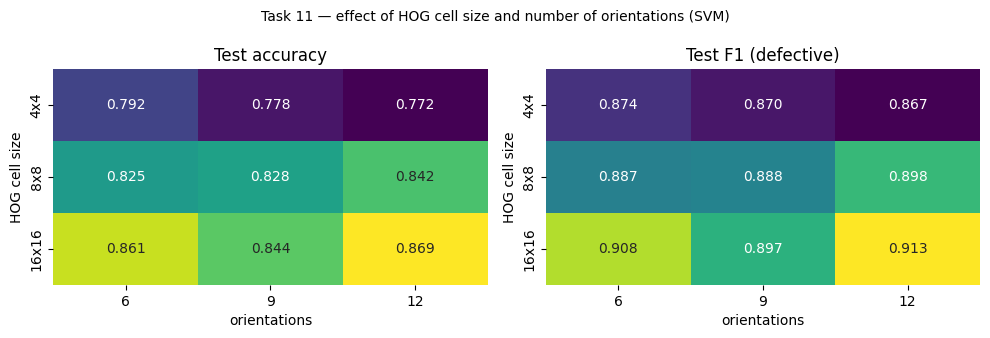

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, col, ttl in zip(axes, ["Test_Acc", "Test_F1"], ["Test accuracy", "Test F1 (defective)"]):
    pv = sweep.pivot(index="Cell", columns="Orient", values=col).loc[["4x4", "8x8", "16x16"]]
    sns.heatmap(pv, annot=True, fmt=".3f", cmap="viridis", ax=ax, cbar=False)
    ax.set_title(ttl); ax.set_ylabel("HOG cell size"); ax.set_xlabel("orientations")
plt.suptitle("Task 11 — effect of HOG cell size and number of orientations (SVM)", fontsize=10)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_hog_params.png", dpi=150); plt.show()

## Tasks 7–10 — Classifier comparison, confusion matrices, classification reports

Using the selected HOG configuration, four classifiers are compared: **SVM (RBF)**, **Random Forest**, **Logistic Regression**, **k-NN (k=5)**. Positive class = *Defective*.

In [8]:
Ftr = extract_hog(Xtr_img, BEST_CELL, BEST_ORI)
Fva = extract_hog(Xva_img, BEST_CELL, BEST_ORI)
Fte = extract_hog(Xte_img, BEST_CELL, BEST_ORI)

models = {
    "SVM (RBF)": SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", probability=True, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", n_jobs=-1, random_state=SEED),
    "Logistic Regression": LogisticRegression(C=1.0, max_iter=2000, class_weight="balanced"),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5),
}
comp_rows, preds = [], {}
for name, m in models.items():
    t0 = time.time(); m.fit(Ftr, ytr); fit_t = time.time() - t0
    p = m.predict(Fte); preds[name] = p
    r = bin_metrics(yte, p); r.update(Classifier=name, Train_s=fit_t)
    comp_rows.append(r)
comp = pd.DataFrame(comp_rows)[["Classifier", "Accuracy", "Precision", "Recall", "F1", "Train_s"]]
display(comp.round(4))

for name in models:
    print("=" * 62, "\n", name, "- classification report (test)\n", "=" * 62)
    print(classification_report(yte, preds[name], target_names=["Non-defective", "Defective"], digits=4))

,Classifier,Accuracy,Precision,Recall,F1,Train_s
0,SVM (RBF),0.8694,0.9084,0.9185,0.9134,13.1782
1,Random Forest,0.7833,0.7759,1.0000,0.8738,26.2948
2,Logistic Regression,0.8389,0.9454,0.8333,0.8858,0.6865
3,k-NN (k=5),0.5972,0.9371,0.4963,0.6489,0.0038


 SVM (RBF) - classification report (test)
               precision    recall  f1-score   support

Non-defective     0.7471    0.7222    0.7345        90
    Defective     0.9084    0.9185    0.9134       270

     accuracy                         0.8694       360
    macro avg     0.8278    0.8204    0.8240       360
 weighted avg     0.8681    0.8694    0.8687       360

 Random Forest - classification report (test)
               precision    recall  f1-score   support

Non-defective     1.0000    0.1333    0.2353        90
    Defective     0.7759    1.0000    0.8738       270

     accuracy                         0.7833       360
    macro avg     0.8879    0.5667    0.5545       360
 weighted avg     0.8319    0.7833    0.7142       360

 Logistic Regression - classification report (test)
               precision    recall  f1-score   support

Non-defective     0.6311    0.8556    0.7264        90
    Defective     0.9454    0.8333    0.8858       270

     accuracy              

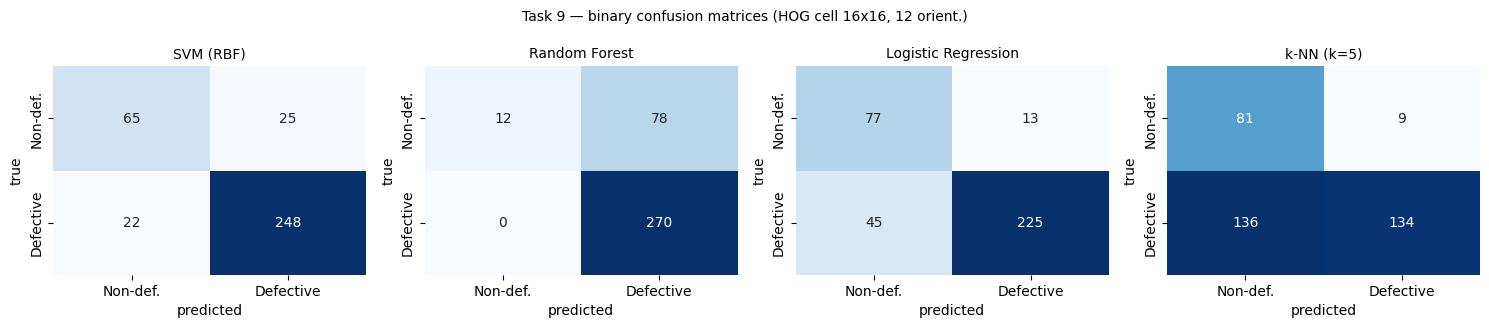

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.3))
for ax, name in zip(axes, models):
    cm = confusion_matrix(yte, preds[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Non-def.", "Defective"], yticklabels=["Non-def.", "Defective"])
    ax.set_title(name, fontsize=10); ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.suptitle(f"Task 9 — binary confusion matrices (HOG cell {BEST_CELL}x{BEST_CELL}, {BEST_ORI} orient.)", fontsize=10)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_confusion_binary.png", dpi=150); plt.show()

### Advanced: 6-class defect classification (real NEU-DET labels only)

Same HOG features, trained on defective images only, to identify *which* defect is present.

,Classifier,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,SVM (RBF),0.7037,0.7299,0.7037,0.7090
1,Random Forest,0.6481,0.6784,0.6481,0.6475


                 precision    recall  f1-score   support

        crazing     0.5079    0.7111    0.5926        45
      inclusion     0.7400    0.8222    0.7789        45
        patches     0.8235    0.6222    0.7089        45
 pitted_surface     0.9459    0.7778    0.8537        45
rolled-in_scale     0.6250    0.6667    0.6452        45
      scratches     0.7368    0.6222    0.6747        45

       accuracy                         0.7037       270
      macro avg     0.7299    0.7037    0.7090       270
   weighted avg     0.7299    0.7037    0.7090       270



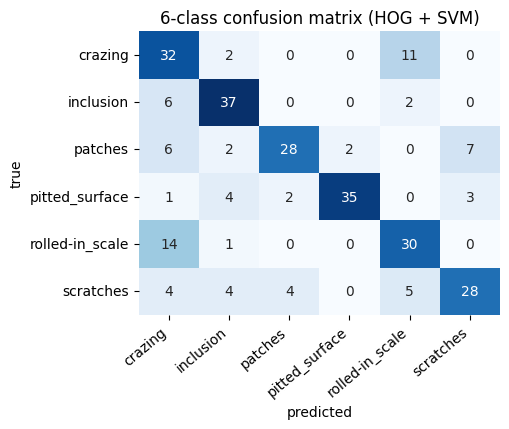

In [10]:
dtr, dte = mtr >= 0, mte >= 0
multi_models = {
    "SVM (RBF)": SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
}
multi_rows, multi_preds = [], {}
for name, m in multi_models.items():
    m.fit(Ftr[dtr], mtr[dtr]); p = m.predict(Fte[dte]); multi_preds[name] = p
    multi_rows.append(dict(Classifier=name, Accuracy=accuracy_score(mte[dte], p),
                           Macro_Precision=precision_score(mte[dte], p, average="macro", zero_division=0),
                           Macro_Recall=recall_score(mte[dte], p, average="macro", zero_division=0),
                           Macro_F1=f1_score(mte[dte], p, average="macro", zero_division=0)))
multi = pd.DataFrame(multi_rows); display(multi.round(4))
print(classification_report(mte[dte], multi_preds["SVM (RBF)"], target_names=CLASSES, digits=4))

fig, ax = plt.subplots(figsize=(5.2, 4.4))
sns.heatmap(confusion_matrix(mte[dte], multi_preds["SVM (RBF)"]), annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False)
ax.set_title("6-class confusion matrix (HOG + SVM)"); ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.xticks(rotation=40, ha="right"); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_confusion_multiclass.png", dpi=150); plt.show()

## Task 12 — Robustness under realistic imaging conditions

The trained models are **not retrained**; the *test images* are degraded (after resize / grayscale) and the same HOG + classifier pipeline is applied. Four families of disturbance are tested: **brightness**, **Gaussian noise**, **rotation**, **blur** (two severities each). Change in accuracy and F1 is reported against the clean test set.

As an extra, an **augmentation-trained SVM** (training set doubled with randomly degraded copies) is evaluated under the same conditions.

In [11]:
def brightness(img, beta, rng=None):  return cv2.convertScaleAbs(img, alpha=1.0, beta=beta)
def gnoise(img, sigma, rng):          return np.clip(img.astype(np.float32) + rng.normal(0, sigma, img.shape), 0, 255).astype(np.uint8)
def rotate(img, deg, rng=None):
    M = cv2.getRotationMatrix2D((IMG_SIZE / 2, IMG_SIZE / 2), deg, 1.0)
    return cv2.warpAffine(img, M, (IMG_SIZE, IMG_SIZE), borderMode=cv2.BORDER_REFLECT_101)
def blur(img, k, rng=None):           return cv2.GaussianBlur(img, (k, k), k / 3.0)

CONDITIONS = {
    "Brightness +50": lambda im, r: brightness(im, 50),
    "Brightness -50": lambda im, r: brightness(im, -50),
    "Gaussian noise s=10": lambda im, r: gnoise(im, 10, r),
    "Gaussian noise s=25": lambda im, r: gnoise(im, 25, r),
    "Rotation 10 deg": lambda im, r: rotate(im, 10),
    "Rotation 30 deg": lambda im, r: rotate(im, 30),
    "Blur k=5": lambda im, r: blur(im, 5),
    "Blur k=9": lambda im, r: blur(im, 9),
}
def perturb_all(imgs, fn, seed=SEED):
    rng = np.random.default_rng(seed)
    return np.array([fn(im, rng) for im in imgs])

rng_aug = np.random.default_rng(SEED + 1)
mild = [lambda im, r: brightness(im, int(r.integers(-40, 41))), lambda im, r: gnoise(im, float(r.uniform(5, 20)), r),
        lambda im, r: rotate(im, float(r.uniform(-20, 20))), lambda im, r: blur(im, int(r.choice([3, 5, 7])))]
aug_imgs = np.array([mild[rng_aug.integers(0, 4)](im, rng_aug) for im in Xtr_img])
aug_svm = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced").fit(
    np.vstack([Ftr, extract_hog(aug_imgs, BEST_CELL, BEST_ORI)]), np.concatenate([ytr, ytr]))

rob_models = {"SVM": models["SVM (RBF)"], "RF": models["Random Forest"], "SVM+aug": aug_svm}
rob_rows = []
clean = {n: bin_metrics(yte, m.predict(Fte)) for n, m in rob_models.items()}
for n in rob_models:
    rob_rows.append(dict(Condition="Clean", Model=n, Accuracy=clean[n]["Accuracy"], F1=clean[n]["F1"], dAcc=0.0, dF1=0.0))
for cname, fn in CONDITIONS.items():
    Fp = extract_hog(perturb_all(Xte_img, fn), BEST_CELL, BEST_ORI)
    for n, m in rob_models.items():
        r = bin_metrics(yte, m.predict(Fp))
        rob_rows.append(dict(Condition=cname, Model=n, Accuracy=r["Accuracy"], F1=r["F1"],
                             dAcc=r["Accuracy"] - clean[n]["Accuracy"], dF1=r["F1"] - clean[n]["F1"]))
rob = pd.DataFrame(rob_rows)
display(rob.pivot(index="Condition", columns="Model", values=["Accuracy", "F1", "dAcc", "dF1"])
        .reindex(["Clean"] + list(CONDITIONS)).round(4))

Accuracy                      F1                    dAcc  \
Model                     RF     SVM SVM+aug      RF     SVM SVM+aug      RF   
Condition                                                                      
Clean                 0.7833  0.8694  0.8361  0.8738  0.9134  0.8925  0.0000   
Brightness +50        0.7833  0.8694  0.8361  0.8738  0.9134  0.8925  0.0000   
Brightness -50        0.7833  0.8694  0.8361  0.8738  0.9134  0.8925  0.0000   
Gaussian noise s=10   0.7500  0.7500  0.7139  0.8571  0.8571  0.8245 -0.0333   
Gaussian noise s=25   0.7500  0.7500  0.6417  0.8571  0.8571  0.7659 -0.0333   
Rotation 10 deg       0.7500  0.7528  0.8306  0.8571  0.8585  0.8885 -0.0333   
Rotation 30 deg       0.7500  0.7500  0.7472  0.8571  0.8571  0.8515 -0.0333   
Blur k=5              0.7500  0.7556  0.8000  0.8571  0.8594  0.8696 -0.0333   
Blur k=9              0.7500  0.7500  0.7500  0.8571  0.8571  0.8571 -0.0333   

                                        dF1                  
Model                   SVM SVM+aug      RF     SVM SVM+aug  
Condition                                                    
Clean                0.0000  0.0000  0.0000  0.0000  0.0000  
Brightness +50       0.0000  0.0000  0.0000  0.0000  0.0000  
Brightness -50       0.0000  0.0000  0.0000  0.0000  0.0000  
Gaussian noise s=10 -0.1194 -0.1222 -0.0166 -0.0563 -0.0680  
Gaussian noise s=25 -0.1194 -0.1944 -0.0166 -0.0563 -0.1267  
Rotation 10 deg     -0.1167 -0.0056 -0.0166 -0.0549 -0.0040  
Rotation 30 deg     -0.1194 -0.0889 -0.0166 -0.0563 -0.0410  
Blur k=5            -0.1139 -0.0361 -0.0166 -0.0540 -0.0230  
Blur k=9            -0.1194 -0.0861 -0.0166 -0.0563 -0.0354

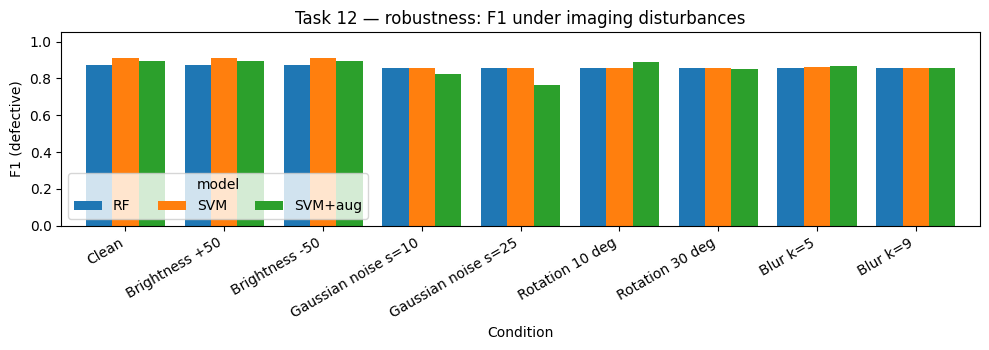

In [12]:
fig, ax = plt.subplots(figsize=(10, 3.6))
order = ["Clean"] + list(CONDITIONS)
pv = rob.pivot(index="Condition", columns="Model", values="F1").reindex(order)
pv.plot.bar(ax=ax, width=0.8); ax.set_ylabel("F1 (defective)"); ax.set_ylim(0, 1.05)
ax.set_title("Task 12 — robustness: F1 under imaging disturbances"); plt.xticks(rotation=30, ha="right")
ax.legend(title="model", ncol=3, loc="lower left"); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_robustness.png", dpi=150); plt.show()

## Task 13 — Industrial quality-control decision module

`inspect_product()` runs the full pipeline (preprocess → HOG → SVM) on one image and prints the inspection result. Because a **missed defect is more expensive than a false rejection**, the reject threshold on the defect probability is a configurable parameter (default 0.5).

In [13]:
final_model = models["SVM (RBF)"]
joblib.dump(dict(model=final_model, cell=BEST_CELL, ori=BEST_ORI, img_size=IMG_SIZE), f"{OUT_DIR}/hog_svm_model.joblib")

def inspect_product(image, model=final_model, cell=BEST_CELL, ori=BEST_ORI, threshold=0.5, show=True):
    if isinstance(image, str):
        image = cv2.imread(image)
    feat = hog_one(preprocess(image), cell, ori).reshape(1, -1)
    p_def = float(model.predict_proba(feat)[0, 1])
    defective = p_def >= threshold
    conf = p_def if defective else 1 - p_def
    if show:
        print("PRODUCT INSPECTION RESULT")
        print(f"Prediction: {'DEFECTIVE' if defective else 'NON-DEFECTIVE'}")
        print(f"Confidence: {conf * 100:.1f}%")
        print(f"Action: {'REJECT PRODUCT' if defective else 'ACCEPT PRODUCT'}")
    return defective, conf

demo = list(np.where(yte == 1)[0][:2]) + list(np.where(yte == 0)[0][:2])
for k in demo:
    print(f"\n--- test image #{k}  (ground truth: {'DEFECTIVE' if yte[k] else 'NON-DEFECTIVE'}) ---")
    inspect_product(Xte_img[k])


--- test image #1  (ground truth: DEFECTIVE) ---
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 100.0%
Action: REJECT PRODUCT

--- test image #5  (ground truth: DEFECTIVE) ---
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 100.0%
Action: REJECT PRODUCT

--- test image #0  (ground truth: NON-DEFECTIVE) ---
PRODUCT INSPECTION RESULT
Prediction: NON-DEFECTIVE
Confidence: 66.0%
Action: ACCEPT PRODUCT

--- test image #2  (ground truth: NON-DEFECTIVE) ---
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 54.0%
Action: REJECT PRODUCT


In [14]:

p_def = final_model.predict_proba(Fte)[:, 1]
thr_rows = []
for t in (0.3, 0.5, 0.7):
    pr = (p_def >= t).astype(int); tn, fp, fn, tp = confusion_matrix(yte, pr).ravel()
    thr_rows.append(dict(Threshold=t, Missed_defects_FN=int(fn), False_rejects_FP=int(fp),
                         Recall=tp / (tp + fn), Precision=tp / max(tp + fp, 1)))
thr = pd.DataFrame(thr_rows); display(thr.round(4))


t0 = time.time()
for k in range(min(50, len(Xte_img))): inspect_product(Xte_img[k], show=False)
LATENCY_MS = (time.time() - t0) / min(50, len(Xte_img)) * 1000
print(f"Mean pipeline latency: {LATENCY_MS:.1f} ms / image")

,Threshold,Missed_defects_FN,False_rejects_FP,Recall,Precision
0,0.3,14,45,0.9481,0.8505
1,0.5,22,26,0.9185,0.9051
2,0.7,39,14,0.8556,0.9429


Mean pipeline latency: 6.8 ms / image
